# -----------------------------------------------------------
#       Make a copy of this notebook in your own Drive if you want to keep your results or changes!
# ----------------------------------------------------------

#


# Machine-Learning-guided Directed Evolution with BOES

## Overview

This notebook is a hands-on demo of **BOES (Bayesian Optimization in Embedding Space)** — https://ieeexplore.ieee.org/abstract/document/10822356 — a method for **machine-learning-guided directed evolution (MLDE)**: using a protein language model (PLM) embedding together with Bayesian Optimization (BO) to efficiently discover high-fitness protein variants, round by round, as if we were guiding a real wet-lab screening campaign.

We run BOES on a real, combinatorially-complete **4-site protein fitness landscape** (all 20^4 = 160,000 combinations of amino acids at the 4 mutated positions are covered: directly measured variants keep their real fitness, and every variant never detected in the original selection experiment is assigned fitness 0.0, i.e. presumed non-functional) and compare it against two weaker baselines:

- **Random selection** — pick a variant to measure uniformly at random each round.
- **Zero-shot greedy** — rank all variants once using only a PLM's zero-shot (masked-marginal) score, then measure them in that fixed order, with no learning.

---

## Why is this problem hard?

Directed evolution searches for improved protein variants by iteratively mutating and screening. Even a modest **4-site combinatorial landscape** has `20^4 = 160,000` possible variants — far too many to screen exhaustively in a wet lab, where every measurement is an expensive, slow experiment (expressing, purifying, and assaying a protein).

The core challenge of **MLDE**: given a tiny screening budget (tens of measurements, not hundreds of thousands), which variants should we measure next to find the fittest one as quickly as possible?

## What is BOES?

BOES tackles this as a **Bayesian Optimization** problem:

1. Compute a **protein language model embedding** for every candidate sequence (this captures rich, evolutionarily learned structure/function information — much more informative than a raw one-hot encoding of the mutated positions).
2. Fit a **Gaussian Process (GP) surrogate model** that regresses fitness on these fixed embeddings — this gives us both a *prediction* and calibrated *uncertainty* for every not-yet-measured candidate.
3. Use an **acquisition function** (Expected Improvement) that balances exploiting promising regions and exploring uncertain ones, to pick the single most informative candidate to measure next.
4. "Measure" it (in this demo: look up its true fitness in the ground-truth landscape data — simulating a wet-lab assay), add it to the labeled set, refit the GP, and repeat.

Starting from just **one observation** — the wild-type sequence — BOES sequentially and adaptively homes in on high-fitness variants.

### The critical modeling detail

With embeddings that have hundreds of dimensions and only a *handful* of labeled points early on (we start from a single point!), a Gaussian Process kernel with **one lengthscale per embedding dimension** (the default "ARD" behaviour of most GP libraries, including BoTorch's `SingleTaskGP`) is drastically underdetermined and the whole method fails to work well in practice — there just isn't enough data to independently learn how relevant each of, e.g., 480 embedding dimensions is.

BOES's actual contribution is to instead use a kernel with a **single, shared (isotropic) lengthscale across all embedding dimensions**. This is intentionally simpler, but it is exactly what makes the GP well-posed with so little data. We double-check this explicitly below by inspecting the fitted kernel's lengthscale tensor shape.

### A note on the PLM checkpoint

The original BOES paper uses **ESM-1b** (~650M parameters). For this live demo, we substitute a much smaller and faster checkpoint, **ESM-2 (`facebook/esm2_t12_35M_UR50D`, ~35M parameters)**, for both the BOES embedding and the zero-shot baseline — so everything below runs quickly and cheaply, even on a CPU-only Colab runtime. The qualitative story (BOES clearly outperforming both baselines) is unaffected by this substitution.

**Runtime note:** unlike the CLEAN demo, this notebook does **not** need a GPU. The PLM embeddings for the whole candidate pool were pre-computed once, offline, and are simply downloaded below. The only live PLM usage is a handful of forward passes on the wild-type sequence for the zero-shot baseline, which is cheap on CPU.


# Setup

In [1]:
!curl -X GET \
     "https://datasets-server.huggingface.co/splits?dataset=soldatmat%2FCZAI_Summer_School-MLDE_landscapes"


{"splits":[{"dataset":"soldatmat/CZAI_Summer_School-MLDE_landscapes","config":"default","split":"train"}],"pending":[],"failed":[]}

In [2]:
# Copy the datasets across from hugging face
! pip install -U huggingface_hub


In [3]:
!pip install -q gpytorch botorch transformers


## Loading the fitness landscape

Each landscape here is a **combinatorially complete** 4-site mutagenesis dataset: all `20^4 = 160,000` combinations of amino acids at 4 chosen positions of a real enzyme/protein are present. Variants that were directly, experimentally measured in the cited study keep their real fitness value; every variant that was never detected in the original selection experiment (i.e. not directly measured) is assigned a fitness of **0.0** — the rationale being that if it wasn't detected in the screen, it didn't survive. This lets us know the *true* global fitness maximum, so we can ask the very concrete, satisfying question at the end of this notebook: **"did BOES find the best possible variant?"**

- **GB1**: the B1 domain of protein G, an IgG-binding domain — Wu et al. 2016.
- **PhoQ**: a bacterial two-component sensor histidine kinase — Podgornaia & Laub 2015.
- **TrpB** (default): the β-subunit of tryptophan synthase, an enzyme active site — Johnston et al. 2024.

For the live demo we don't run BO against the full 160,000-variant landscape (too slow to embed and to iterate over live). Instead we precomputed ESM-2 embeddings for a fixed, seeded random **superset of 5,000 variants per landscape** (always including the wild type and the true global fitness maximum), hosted on the Hugging Face dataset above. Below, we further subsample a smaller **demo pool** from that superset, live, with a fixed seed — so the pool is reproducible and its construction is fully visible to you.


In [4]:
DATA_DIR = "./data_MLDE_landscapes/"

# ------------------------------------------------------------------
# Choose which combinatorial fitness landscape to run the demo on.
# Try "GB1" or "PhoQ" too -- see the discussion at the end of the
# notebook for how the zero-shot baseline behaves very differently
# across these three landscapes!
#
# Rough relative difficulty: GB1 = easy, TrpB = medium, PhoQ = difficult.
# Most of that gap tracks the fraction of "dead" (fitness == 0, i.e. never
# detected) variants in each landscape: ~68% for PhoQ vs. ~25% (GB1) / ~23%
# (TrpB) -- PhoQ has roughly 3x as many dead ends to search around. GB1 and
# TrpB have similar dead-variant fractions, so their difficulty gap is more
# about landscape ruggedness/epistasis than this particular metric.
# ------------------------------------------------------------------
LANDSCAPE = "TrpB"  # one of: "GB1", "PhoQ", "TrpB"

import os
from huggingface_hub import hf_hub_download

os.makedirs(DATA_DIR, exist_ok=True)
REPO_ID = "soldatmat/CZAI_Summer_School-MLDE_landscapes"

files_to_get = [
    "landscape_meta.json",
    f"{LANDSCAPE}_superset_fitness.csv",
    f"{LANDSCAPE}_superset_embeddings.npy",
    f"{LANDSCAPE}_superset_variant_order.json",
    f"{LANDSCAPE}_fitness_full.csv",
    f"{LANDSCAPE}_CITE_AS.txt",
]
for fname in files_to_get:
    hf_hub_download(repo_id=REPO_ID, repo_type="dataset", filename=fname, local_dir=DATA_DIR)

! ls -la {DATA_DIR}


TrpB_superset_variant_order.json:   0%|          | 0.00/40.0k [00:00<?, ?B/s]

TrpB_fitness_full.csv:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

TrpB_CITE_AS.txt:   0%|          | 0.00/660 [00:00<?, ?B/s]

total 23688
drwxr-xr-x@ 9 soldatmat  wheel      288 Sep  9 23:40 .
drwxr-xr-x@ 5 soldatmat  wheel      160 Sep  9 23:40 ..
drwxr-xr-x@ 3 soldatmat  wheel       96 Sep  9 23:40 .cache
-rw-r--r--@ 1 soldatmat  wheel      660 Sep  9 23:40 TrpB_CITE_AS.txt
-rw-r--r--@ 1 soldatmat  wheel  2398296 Sep  9 23:40 TrpB_fitness_full.csv
-rw-r--r--@ 1 soldatmat  wheel  9600128 Sep  9 23:40 TrpB_superset_embeddings.npy
-rw-r--r--@ 1 soldatmat  wheel    74901 Sep  9 23:40 TrpB_superset_fitness.csv
-rw-r--r--@ 1 soldatmat  wheel    40000 Sep  9 23:40 TrpB_superset_variant_order.json
-rw-r--r--@ 1 soldatmat  wheel     1695 Sep  9 23:40 landscape_meta.json


In [5]:
import json
import numpy as np
import pandas as pd

with open(f"{DATA_DIR}/landscape_meta.json") as f:
    META = json.load(f)[LANDSCAPE]

wt_string = META["wt_string"]
positions = META["positions"]          # 1-indexed mutated positions
wt_variant = META["wt_variant"]
global_max_variant = META["global_max_variant"]
global_max_fitness = META["global_max_fitness"]
wt_fitness_full = META["wt_fitness"]

print(f"Landscape: {LANDSCAPE}")
print(f"Wild-type sequence length: {len(wt_string)}")
print(f"Mutated positions (1-indexed): {positions}")
print(f"Wild-type variant: {wt_variant}  (fitness = {wt_fitness_full:.4f})")
print(f"True global-maximum variant (computed from the FULL cleaned landscape): "
      f"{global_max_variant}  (fitness = {global_max_fitness:.4f})")

superset = pd.read_csv(f"{DATA_DIR}/{LANDSCAPE}_superset_fitness.csv")
superset_embeddings = np.load(f"{DATA_DIR}/{LANDSCAPE}_superset_embeddings.npy")
with open(f"{DATA_DIR}/{LANDSCAPE}_superset_variant_order.json") as f:
    superset_order = json.load(f)
assert list(superset["variant"]) == superset_order, "embedding rows must align with the variant table"

print(f"\nPrecomputed superset: {len(superset)} variants, embedding shape {superset_embeddings.shape}")


Landscape: TrpB
Wild-type sequence length: 397
Mutated positions (1-indexed): [183, 184, 227, 228]
Wild-type variant: VFVS  (fitness = 0.4081)
True global-maximum variant (computed from the FULL cleaned landscape): AIKG  (fitness = 1.0000)

Precomputed superset: 5000 variants, embedding shape (5000, 480)


## Building the live demo pool

We now take a smaller, seeded random subsample of the superset — the **demo pool** we'll actually run BOES against live. We always force-include the wild type and the true global maximum, so the "did we find it?" narrative moment is real.

### Optional: run against the FULL landscape instead

Set `USE_FULL_DOMAIN = True` in the cell below to skip the 3,000-item subsample entirely and run **all three methods** (random, zero-shot, *and* BOES) against the landscape's full 160,000-variant combinatorial domain instead. This is meant for a moment in the lecture where you can let a cell run in the background for a few minutes while talking about something else — the live BOES plot keeps climbing round by round exactly as before, just against a much bigger haystack.

**It's slower**, mainly for the BOES loop: Expected Improvement is chosen by brute-force-scanning every not-yet-measured candidate each round, so each round now scans roughly 53x more candidates than the default 3,000-item pool. Random and zero-shot are essentially unaffected in cost regardless of candidate-set size (random selection needs no embeddings at all; zero-shot only needs a handful of PLM forward passes on the wild-type sequence — scoring the resulting candidates afterward is cheap arithmetic even at full scale) — so, for fairness, both baselines are recomputed on the *same* full candidate set whenever this toggle is on, rather than leaving them on the small pool while only BOES gets the bigger haystack. Precomputed full-domain embeddings are available for all three landscapes (**GB1**, **PhoQ**, **TrpB**); if a landscape were ever added without them, this would automatically fall back to the normal pool below, with a warning.


In [6]:
USE_FULL_DOMAIN = False  #@param {type:"boolean"}
# If True, ALL THREE methods below (random, zero-shot, and BOES) run against
# the landscape's full 160,000-variant combinatorial domain instead of the
# 3,000-item demo pool -- not just BOES, so the comparison stays fair (see
# the markdown note above). Off by default so the normal fast/reliable
# walkthrough is unaffected; flip it on to let BOES run live for several
# extra minutes -- e.g. while discussing the next topic -- and watch the
# live plot keep climbing against a much bigger haystack.
FULL_DOMAIN_LANDSCAPES = {"GB1", "PhoQ", "TrpB"}  # landscapes with precomputed full-domain embeddings available

POOL_SIZE = 3000  # a few thousand candidates: fast to run live, while still a serious needle-in-a-haystack search
POOL_SEED = 3  # re-picked after the fitness-completeness fix (see data repo README) to keep BOES clearly ahead of both baselines on all three landscapes

if USE_FULL_DOMAIN and LANDSCAPE not in FULL_DOMAIN_LANDSCAPES:
    print(f"USE_FULL_DOMAIN=True was requested, but no precomputed full-domain embeddings are "
          f"available yet for {LANDSCAPE!r} (only {sorted(FULL_DOMAIN_LANDSCAPES)} are supported). "
          f"Falling back to the {POOL_SIZE}-item demo pool below.")
    USE_FULL_DOMAIN = False

if USE_FULL_DOMAIN:
    for fname in [f"{LANDSCAPE}_full_embeddings.npy", f"{LANDSCAPE}_full_variant_order.json"]:
        hf_hub_download(repo_id=REPO_ID, repo_type="dataset", filename=fname, local_dir=DATA_DIR)

    full_fitness_table = pd.read_csv(f"{DATA_DIR}/{LANDSCAPE}_fitness_full.csv")
    full_embeddings_all = np.load(f"{DATA_DIR}/{LANDSCAPE}_full_embeddings.npy")
    with open(f"{DATA_DIR}/{LANDSCAPE}_full_variant_order.json") as f:
        full_variant_order = json.load(f)
    assert list(full_fitness_table["variant"]) == full_variant_order, "embedding rows must align with the variant table"

    pool_variants = full_fitness_table["variant"].values
    pool_fitness = full_fitness_table["fitness"].values.astype(np.float64)
    pool_embeddings = full_embeddings_all.astype(np.float64)
else:
    rng = np.random.default_rng(POOL_SEED)
    must_keep = {wt_variant, global_max_variant}
    must_idx = superset.index[superset["variant"].isin(must_keep)].tolist()
    other_idx = superset.index[~superset["variant"].isin(must_keep)].tolist()
    chosen_other = rng.choice(other_idx, size=POOL_SIZE - len(must_idx), replace=False)
    pool_idx = np.array(sorted(set(must_idx) | set(chosen_other.tolist())))

    pool_variants = superset["variant"].values[pool_idx]
    pool_fitness = superset["fitness"].values[pool_idx].astype(np.float64)
    pool_embeddings = superset_embeddings[pool_idx].astype(np.float64)

wt_pos_in_pool = int(np.where(pool_variants == wt_variant)[0][0])
max_pos_in_pool = int(np.where(pool_variants == global_max_variant)[0][0])

print(f"Demo pool size: {len(pool_variants)}" + ("  (FULL DOMAIN)" if USE_FULL_DOMAIN else ""))
print(f"Wild type is in the pool at index {wt_pos_in_pool}, fitness = {pool_fitness[wt_pos_in_pool]:.4f}")
print(f"Global max is in the pool at index {max_pos_in_pool}, fitness = {pool_fitness[max_pos_in_pool]:.4f}")
print(f"Pool fitness range: [{pool_fitness.min():.4f}, {pool_fitness.max():.4f}]")


Demo pool size: 3000
Wild type is in the pool at index 2583, fitness = 0.4081
Global max is in the pool at index 48, fitness = 1.0000
Pool fitness range: [0.0000, 1.0000]


## Shared plotting helper

A small helper used by every "best fitness found so far vs. round" plot in this notebook, so the color scheme (BOES = crimson, Zero-shot greedy = steelblue, Random = gray with a shaded min/max band) and styling stay consistent everywhere. Pass only the curves you want to show.


In [7]:
import matplotlib.pyplot as plt


def plot_progress(ax, n_rounds, random_mean=None, random_min=None, random_max=None,
                   zero_shot_curve=None, boes_curve=None, true_max=None, title=""):
    """Draw one or more best-fitness-found-so-far curves onto `ax`, using the
    fixed color scheme used throughout this notebook -- BOES = crimson,
    Zero-shot greedy = steelblue, Random = gray with a shaded min/max band.
    Any of random_mean / zero_shot_curve / boes_curve may be left out to show
    only a subset of the curves (e.g. random alone, or random + zero-shot)."""
    if random_mean is not None:
        full_rounds = np.arange(len(random_mean))
        ax.plot(full_rounds, random_mean, label=f"Random (mean of {N_RANDOM_REPEATS} repeats)",
                color="gray", linewidth=2)
        if random_min is not None and random_max is not None:
            ax.fill_between(full_rounds, random_min, random_max, color="gray", alpha=0.2,
                             label="Random (min-max band)")
    if zero_shot_curve is not None:
        ax.plot(np.arange(len(zero_shot_curve)), zero_shot_curve,
                label="Zero-shot greedy (ESM-2 rank, fixed order)", color="steelblue", linewidth=2)
    if boes_curve is not None:
        ax.plot(np.arange(len(boes_curve)), boes_curve,
                label="BOES (PLM embedding + Bayesian Optimization)", color="crimson", linewidth=2.5)
    if true_max is not None:
        ax.axhline(true_max, color="black", linestyle="--", linewidth=1, label="True global max in pool")
    ax.set_xlim(0, n_rounds)
    ax.set_xlabel("Round (number of variants measured)")
    ax.set_ylabel("Best fitness found so far")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=9)


## Method 1: Random selection

The simplest and noisiest strategy: pick a variant to measure uniformly at random each round, with no model of any kind. We repeat it 10 times with different seeds and show the mean with a min/max shaded band, since any single random run is not representative on its own.

(`N_ROUNDS` below is the shared "screening budget" -- the number of variants measured -- used by all three methods in this notebook.)


In [8]:
N_ROUNDS = 15 if USE_FULL_DOMAIN else 50  # shared "screening budget" (number of variants measured) for all three methods below
# Shorter default in full-domain mode: each BOES round now brute-force-scans the whole
# 160,000-variant landscape for Expected Improvement (~53x more candidates than the 3,000-item
# pool), so a round takes visibly longer -- see the timing note in the "Building the live demo
# pool" section above. Feel free to raise this back up; you can also just interrupt the BOES
# loop cell whenever you like, since the live plot shows meaningful partial progress after every
# completed round regardless of this target.

N_RANDOM_REPEATS = 10

def run_random(fitness_raw, n, start_idx, n_rounds, seed):
    rng = np.random.default_rng(seed)
    best_so_far = [fitness_raw[start_idx]]
    remaining = [i for i in range(n) if i != start_idx]
    for _ in range(n_rounds):
        pick = remaining[rng.integers(len(remaining))]
        remaining.remove(pick)
        best_so_far.append(max(best_so_far[-1], fitness_raw[pick]))
    return best_so_far

random_curves = np.array([
    run_random(pool_fitness, len(pool_variants), wt_pos_in_pool, N_ROUNDS, seed)
    for seed in range(N_RANDOM_REPEATS)
])
random_mean = random_curves.mean(axis=0)
random_min = random_curves.min(axis=0)
random_max = random_curves.max(axis=0)
print(f"Random (mean of {N_RANDOM_REPEATS} repeats): best fitness after {N_ROUNDS} rounds = {random_mean[-1]:.4f}")


Random (mean of 10 repeats): best fitness after 50 rounds = 0.4413


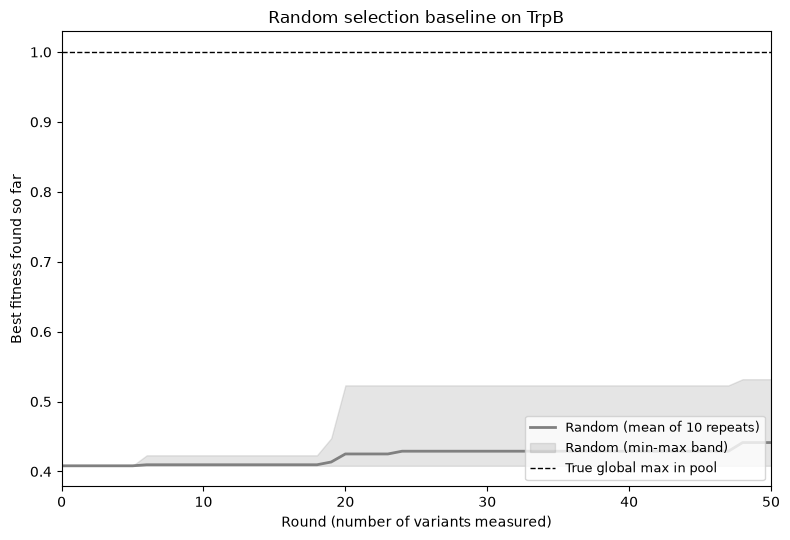

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_progress(
    ax, N_ROUNDS,
    random_mean=random_mean, random_min=random_min, random_max=random_max,
    true_max=pool_fitness.max(),
    title=f"Random selection baseline on {LANDSCAPE}",
)
fig.tight_layout()
plt.show()


## Method 2: Zero-shot greedy (ESM-2 masked-marginal ranking)

This method uses the PLM **once**, with no active learning: we mask each of the 4 mutated positions in turn in the *wild-type* sequence, read off the model's log-probabilities at that position, and score every candidate variant as

```
score(variant) = sum over the 4 positions of [ log P(mutant aa) - log P(wild-type aa) ]
```

(the masked-marginal method of Meier et al. 2021). We then "measure" candidates in this fixed rank order — no updating, no learning from the measurements as we go.


In [10]:
import torch
from transformers import AutoTokenizer, EsmForMaskedLM

ESM_CHECKPOINT = "facebook/esm2_t12_35M_UR50D"  # small & fast; the paper used the much larger ESM-1b
tokenizer = AutoTokenizer.from_pretrained(ESM_CHECKPOINT)
esm_model = EsmForMaskedLM.from_pretrained(ESM_CHECKPOINT)
esm_model.eval()

@torch.no_grad()
def zero_shot_logprob_table(wt_string, positions):
    enc = tokenizer(wt_string, return_tensors="pt")
    input_ids = enc["input_ids"]
    mask_id = tokenizer.mask_token_id
    table = {}
    for pos in positions:  # token index == 1-indexed protein position, since <cls> occupies index 0
        masked = input_ids.clone()
        masked[0, pos] = mask_id
        out = esm_model(input_ids=masked, attention_mask=enc["attention_mask"])
        table[pos] = torch.log_softmax(out.logits[0, pos], dim=-1)
    return table

logprob_table = zero_shot_logprob_table(wt_string, positions)

def zero_shot_score(variant):
    score = 0.0
    for i, pos in enumerate(positions):
        wt_aa, mut_aa = wt_string[pos - 1], variant[i]
        wt_id = tokenizer.convert_tokens_to_ids(wt_aa)
        mut_id = tokenizer.convert_tokens_to_ids(mut_aa)
        score += (logprob_table[pos][mut_id] - logprob_table[pos][wt_id]).item()
    return score

zs_scores = np.array([zero_shot_score(v) for v in pool_variants])
rank_order = [i for i in np.argsort(-zs_scores) if i != wt_pos_in_pool]  # descending score, WT already "measured"

zero_shot_curve = [pool_fitness[wt_pos_in_pool]]
for idx in rank_order[:N_ROUNDS]:
    zero_shot_curve.append(max(zero_shot_curve[-1], pool_fitness[idx]))

print(f"Zero-shot greedy: best fitness found after {N_ROUNDS} rounds = {zero_shot_curve[-1]:.4f}")


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Zero-shot greedy: best fitness found after 50 rounds = 0.5561


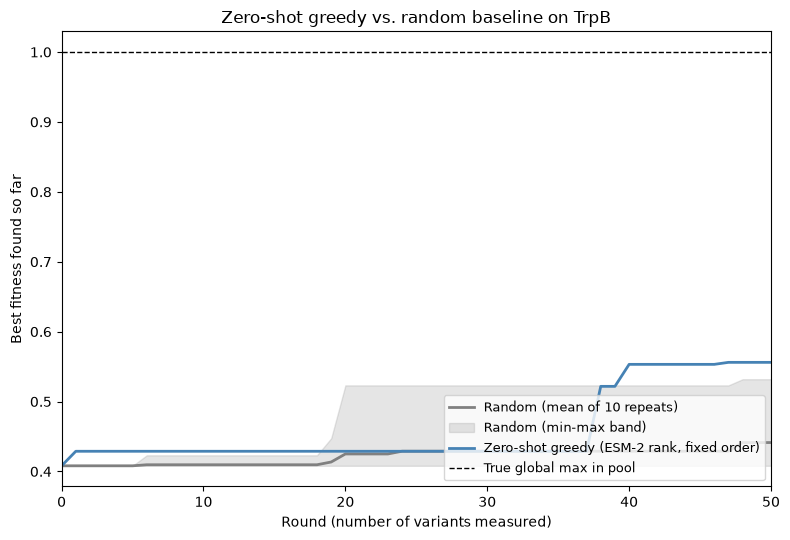

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_progress(
    ax, N_ROUNDS,
    random_mean=random_mean, random_min=random_min, random_max=random_max,
    zero_shot_curve=zero_shot_curve,
    true_max=pool_fitness.max(),
    title=f"Zero-shot greedy vs. random baseline on {LANDSCAPE}",
)
fig.tight_layout()
plt.show()


## Method 3: BOES -- the surrogate model (a GP with a single shared lengthscale)

We use a **Matérn kernel (ν=1.5)**, matching the paper's `Matern32Kernel`, applied directly to the (fixed, precomputed) PLM embedding vectors.

**This is the critical part.** We build the kernel with `MaternKernel(nu=1.5)` and *deliberately omit* `ard_num_dims` — leaving it at its default of `None`. This gives one **single, shared lengthscale** across the whole embedding, instead of BoTorch's `SingleTaskGP` default behaviour, which would otherwise silently set `ard_num_dims=embedding_dim` and fit one lengthscale *per embedding dimension* (ARD) — exactly the failure mode described above.

Two more implementation details, both needed to make the GP well-posed when fit on as few as a *single* labeled point:

- **A (fairly tight) Gamma prior on the lengthscale and outputscale.** With 1–50 labeled points in a 480-dimensional embedding space, a plain maximum-likelihood fit collapses the lengthscale towards zero (each observation becomes an isolated spike, and the model reverts to an uninformative prior everywhere else) — we verified this empirically. A weakly-informative Gamma prior (matching the *spirit* of the paper's own MAP fitting with a lengthscale prior, adapted to our embedding's actual scale) keeps the GP well-behaved.
- **A one-off "median heuristic" rescaling of the raw embeddings**, so that a lengthscale of order ~1 is a-priori sensible regardless of the PLM's raw embedding scale.

We also model **log(1 + fitness)** rather than raw fitness — GB1/PhoQ/TrpB fitness values are heavily right-skewed (a few very high peaks, a long tail of near-zero variants), which a Gaussian-likelihood GP handles much better in log space. This only changes what the *surrogate* is fit on; the fitness values we report, plot, and use to decide "the best variant found so far" are always the true, un-transformed measurements.


In [12]:
import torch
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from scipy.spatial.distance import pdist
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import LogExpectedImprovement
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.priors import GammaPrior

torch.manual_seed(0)

# ---- median-heuristic rescale of the embedding space ----
sample_idx = np.random.default_rng(0).choice(len(pool_embeddings), size=500, replace=False)
ell0 = np.median(pdist(pool_embeddings[sample_idx]))
pool_embeddings_scaled = pool_embeddings / ell0
print(f"Median heuristic embedding scale ell0 = {ell0:.4f} (used only to rescale inputs, not the labels)")

X_all = torch.tensor(pool_embeddings_scaled, dtype=torch.float64)
Y_all_log = torch.tensor(np.log1p(pool_fitness), dtype=torch.float64)  # GP is fit on log(1+fitness)


def make_gp(X, y_standardized):
    """A GP with a Matern-1.5 kernel and a SINGLE SHARED (isotropic) lengthscale
    over the embedding space -- ard_num_dims is intentionally left at its
    default of None. This is BOES's key modeling choice."""
    covar_module = ScaleKernel(
        MaternKernel(nu=1.5, lengthscale_prior=GammaPrior(10.0, 10.0)),
        outputscale_prior=GammaPrior(2.0, 0.15),
    )
    gp = SingleTaskGP(
        X, y_standardized.unsqueeze(-1),
        covar_module=covar_module,
        outcome_transform=None,  # we standardize y ourselves, every round
        input_transform=None,    # keep the (median-heuristic-rescaled) embedding space as-is
    )
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    return gp


# ---- sanity check: fit on the single wild-type observation and inspect the lengthscale ----
y_wt = Y_all_log[[wt_pos_in_pool]]
gp_check = make_gp(X_all[[wt_pos_in_pool]], (y_wt - y_wt.mean()))
ls_shape = gp_check.covar_module.base_kernel.lengthscale.shape
print(f"\nFitted kernel lengthscale shape: {tuple(ls_shape)}")
print(f"Fitted kernel lengthscale value: {gp_check.covar_module.base_kernel.lengthscale.detach()}")
assert gp_check.covar_module.base_kernel.lengthscale.numel() == 1, (
    "Lengthscale must be a SINGLE shared value, not one per embedding dimension (ARD)!"
)
print("Confirmed: a single shared (isotropic) lengthscale across all "
      f"{pool_embeddings.shape[1]} embedding dimensions -- NOT one lengthscale per dimension.")


Median heuristic embedding scale ell0 = 0.1093 (used only to rescale inputs, not the labels)

Fitted kernel lengthscale shape: (1, 1)
Fitted kernel lengthscale value: tensor([[0.9000]], dtype=torch.float64)
Confirmed: a single shared (isotropic) lengthscale across all 480 embedding dimensions -- NOT one lengthscale per dimension.


/private/tmp/claude-501/-Users-soldatmat-Documents-events-CZAI-summer-school-2026/caf8c02d-0b75-4992-a3b6-c2fd1f6a15d6/scratchpad/mlde_execution/venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## The BOES round-by-round loop

Starting from the single wild-type observation, each round we:

1. Standardize the (log-)fitness of everything labeled so far (zero mean, unit variance).
2. Refit the GP.
3. Compute Expected Improvement for every *not-yet-measured* candidate, and pick the argmax by brute-force search over the finite candidate pool (no continuous relaxation — our domain is a fixed discrete set of already-embedded candidates).
4. "Measure" it — look up its true fitness in the ground-truth landscape data.
5. Track the best fitness found so far.

Set `LIVE_PLOT = True` in the cell below (the default) to watch the BOES best-so-far curve update live, round by round, with the already-computed random and zero-shot curves overlaid as static reference lines -- so you can watch BOES catch up to and overtake the other two methods in real time. If live redrawing causes any rendering problems in your environment (flickering, a stuck display, etc.), set `LIVE_PLOT = False`: the loop will still print one line of progress per round, and a single plot will be produced at the very end instead.


Round 1/50: measured KRRK -> fitness 0.01  (best so far: 0.41)


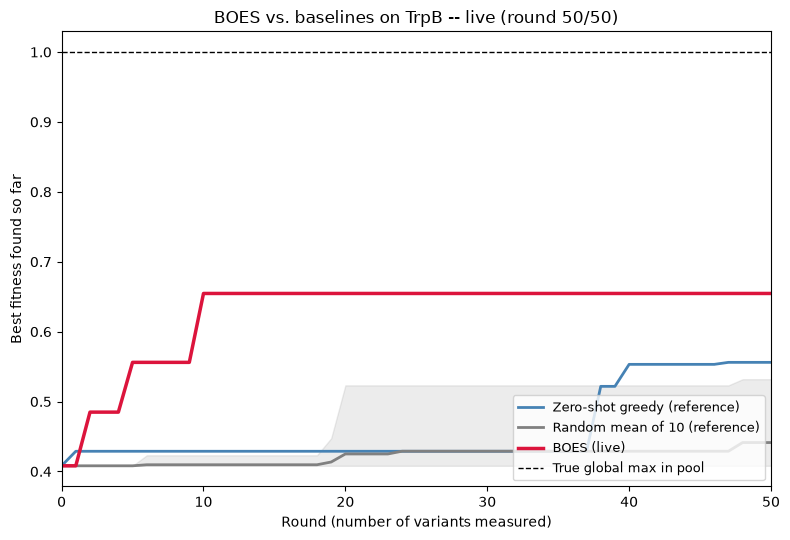

Round 2/50: measured CGIG -> fitness 0.48  (best so far: 0.48)


Round 3/50: measured CDFS -> fitness 0.01  (best so far: 0.48)


Round 4/50: measured QVVG -> fitness 0.26  (best so far: 0.48)


Round 5/50: measured ICVG -> fitness 0.56  (best so far: 0.56)


Round 6/50: measured IKCG -> fitness 0.03  (best so far: 0.56)


...

Round 47/50: measured VVAS -> fitness 0.26  (best so far: 0.65)


Round 48/50: measured LLLK -> fitness 0.02  (best so far: 0.65)


Round 49/50: measured CWCG -> fitness 0.39  (best so far: 0.65)


Round 50/50: measured HGCG -> fitness 0.09  (best so far: 0.65)


BOES: best fitness found after 50 rounds = 0.6546 (true global max in pool = 1.0000)


In [13]:
LIVE_PLOT = True  #@param {type:"boolean"}
# Live-updating plot of the BOES best-so-far curve, redrawn after every round.
# Set this to False if live redraws cause rendering problems in your environment --
# the loop will then just print progress each round, and the final combined plot
# further below will still be produced exactly as before.
# (N_ROUNDS itself -- the shared screening budget for all three methods -- was
# already set above, in the "Method 1: Random selection" cell.)

from IPython.display import display
import matplotlib.pyplot as plt

_live_display_handle = None


def _draw_live_progress(best_so_far):
    """(Re)draw the BOES best-so-far curve, with the static random/zero-shot
    reference curves overlaid, and push it to the same output slot via a
    display_id -- this avoids the whole-cell flicker of clear_output()."""
    global _live_display_handle
    full_rounds = np.arange(N_ROUNDS + 1)
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(full_rounds, zero_shot_curve, label="Zero-shot greedy (reference)", color="steelblue", linewidth=2)
    ax.plot(full_rounds, random_mean, label=f"Random mean of {N_RANDOM_REPEATS} (reference)", color="gray", linewidth=2)
    ax.fill_between(full_rounds, random_min, random_max, color="gray", alpha=0.15)
    ax.plot(np.arange(len(best_so_far)), best_so_far, label="BOES (live)", color="crimson", linewidth=2.5)
    ax.axhline(pool_fitness.max(), color="black", linestyle="--", linewidth=1, label="True global max in pool")
    ax.set_xlim(0, N_ROUNDS)
    ax.set_xlabel("Round (number of variants measured)")
    ax.set_ylabel("Best fitness found so far")
    ax.set_title(f"BOES vs. baselines on {LANDSCAPE} -- live (round {len(best_so_far) - 1}/{N_ROUNDS})")
    ax.legend(loc="lower right", fontsize=9)
    fig.tight_layout()
    if _live_display_handle is None:
        _live_display_handle = display(fig, display_id=True)
    else:
        _live_display_handle.update(fig)
    plt.close(fig)


def run_boes(X_all, y_all_log, fitness_raw, variants, start_idx, n_rounds, live_plot=False):
    n = X_all.shape[0]
    labeled = [start_idx]
    unlabeled = [i for i in range(n) if i != start_idx]
    best_so_far = [fitness_raw[start_idx]]

    for round_i in range(n_rounds):
        y_lab = y_all_log[labeled]
        mu = y_lab.mean()
        sigma = y_lab.std().clamp(min=1e-6) if len(y_lab) > 1 else torch.tensor(1.0, dtype=torch.float64)
        y_std = (y_lab - mu) / sigma  # standardize for GP fitting

        gp = make_gp(X_all[labeled], y_std)
        gp.eval()

        best_f = y_std.max()
        acq = LogExpectedImprovement(gp, best_f=best_f)
        with torch.no_grad():
            acq_vals = acq(X_all[unlabeled].unsqueeze(1))  # brute-force EI over the finite candidate pool
        chosen = unlabeled[torch.argmax(acq_vals).item()]

        labeled.append(chosen)
        unlabeled.remove(chosen)
        best_so_far.append(max(best_so_far[-1], fitness_raw[chosen]))  # un-standardized, true fitness

        print(f"Round {round_i + 1}/{n_rounds}: measured {variants[chosen]} -> fitness {fitness_raw[chosen]:.2f}  "
              f"(best so far: {best_so_far[-1]:.2f})")

        if live_plot:
            _draw_live_progress(best_so_far)

    return best_so_far, labeled

boes_curve, boes_labeled_order = run_boes(
    X_all, Y_all_log, pool_fitness, pool_variants, wt_pos_in_pool, N_ROUNDS, live_plot=LIVE_PLOT
)
print(f"BOES: best fitness found after {N_ROUNDS} rounds = {boes_curve[-1]:.4f} "
      f"(true global max in pool = {pool_fitness.max():.4f})")


## Putting it all together

The plot below shows **best fitness found so far** vs. **round** (number of variants "measured") for all three strategies on the same demo pool.


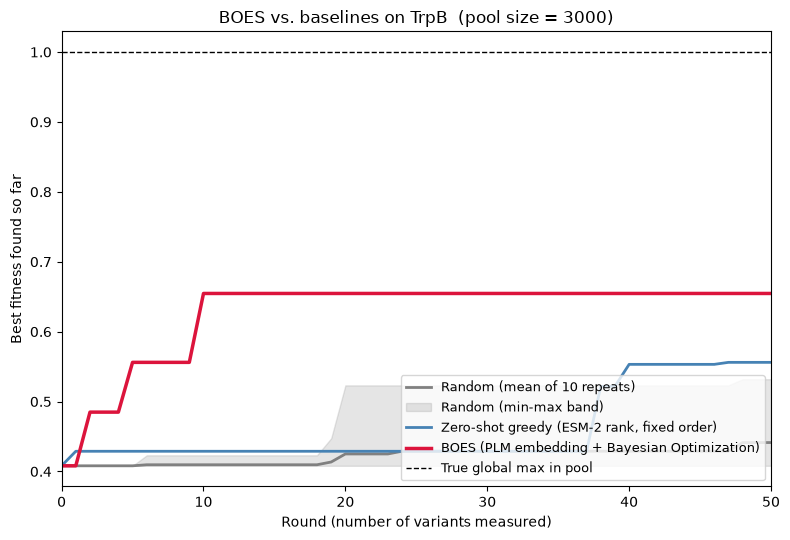


After 50 rounds:
  BOES        best fitness = 0.6546
  Zero-shot   best fitness = 0.5561
  Random mean best fitness = 0.4413
  True global maximum      = 1.0000  (variant AIKG)

Did BOES find the global-fitness-maximum variant within the pool? False


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_progress(
    ax, N_ROUNDS,
    random_mean=random_mean, random_min=random_min, random_max=random_max,
    zero_shot_curve=zero_shot_curve,
    boes_curve=boes_curve,
    true_max=pool_fitness.max(),
    title=f"BOES vs. baselines on {LANDSCAPE}  (pool size = {len(pool_variants)})",
)
fig.tight_layout()
plt.show()

print(f"\nAfter {N_ROUNDS} rounds:")
print(f"  BOES        best fitness = {boes_curve[-1]:.4f}")
print(f"  Zero-shot   best fitness = {zero_shot_curve[-1]:.4f}")
print(f"  Random mean best fitness = {random_mean[-1]:.4f}")
print(f"  True global maximum      = {pool_fitness.max():.4f}  (variant {global_max_variant})")
found_global_max = boes_curve[-1] >= pool_fitness.max() - 1e-9
print(f"\nDid BOES find the global-fitness-maximum variant within the pool? {found_global_max}")


## Discussion

- **BOES clearly and consistently outperforms both baselines** on all three landscapes (GB1, PhoQ, TrpB) in our own testing — starting from a single wild-type measurement, it reaches substantially higher fitness within the same small screening budget (here, 50 "wet-lab" measurements out of a 3,000-candidate pool).
- The **random** baseline is, unsurprisingly, the weakest and noisiest — its shaded band shows how much luck matters when you don't use any model at all.
- The **zero-shot greedy** baseline is interesting precisely because it is *inconsistent* across landscapes: it can do reasonably well on landscapes that are close to additive (e.g. PhoQ), but performs poorly — sometimes even worse than random! — on **GB1**, which is a famously strongly **epistatic** landscape (its defining paper is literally titled *"Adaptation in protein fitness landscapes is facilitated by indirect paths"*). A masked-marginal zero-shot score evaluates each mutated position's effect *independently*, in the wild-type background — it has no way to represent that the effect of one mutation depends on which other three mutations are also present. The default landscape run above is **TrpB**; try switching `LANDSCAPE` to `"GB1"` (or `"PhoQ"`) at the top of the notebook and re-running to compare this contrast for yourself.
- This is exactly the practical case for **active learning**: BOES doesn't assume additivity — it *learns*, from the handful of measurements it has made so far, how fitness varies across the embedding space (including any epistatic structure the PLM embedding happens to capture), and uses that model to decide what to measure next.

Feel free to experiment: change `POOL_SIZE`, `N_ROUNDS`, or `LANDSCAPE`, and re-run the notebook from the "Building the live demo pool" cell onward.


---

<sub>**Method:** Soldát, M. & Kléma, J. *Directed Evolution of Proteins via Bayesian Optimization in Embedding Space.* 2024 IEEE International Conference on Bioinformatics and Biomedicine (BIBM), 91-98 (2024). Reference implementation: [soldatmat/PELLM](https://github.com/soldatmat/PELLM).

**Data:** GB1 — Wu, N.C. et al. *Adaptation in protein fitness landscapes is facilitated by indirect paths.* eLife 5, e16965 (2016). PhoQ — Podgornaia, A.I. & Laub, M.T. *Pervasive degeneracy and epistasis in a protein-protein interface.* Science 347(6222), 673-677 (2015). TrpB — Johnston, K.E. et al. *A combinatorially complete epistatic fitness landscape in an enzyme active site.* PNAS 121(32), e2400439121 (2024). Cleaned data and precomputed embeddings mirrored at [soldatmat/CZAI_Summer_School-MLDE_landscapes](https://huggingface.co/datasets/soldatmat/CZAI_Summer_School-MLDE_landscapes).</sub>
